Импорт библиотек

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE, ADASYN
import warnings
import os
import math

Загрузка датасетов, подготовка признаков и целевой переменной

In [11]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 20
plt.style.use('seaborn-v0_8-whitegrid')


# Пути
train_path = r"C:\Users\Asus\Desktop\AI method\LB_3\data\row\Data_Set_(A+B).csv"
test_path = r"C:\Users\Asus\Desktop\AI method\LB_3\data\row\Data_Set_C.csv"
reports_dir = r"C:\Users\Asus\Desktop\AI method\LB_3\reports"
os.makedirs(reports_dir, exist_ok=True)

# Загрузка и очистка
df = pd.read_csv(train_path, sep=';', decimal=',', encoding='cp1251')
feature_cols = ['I1', 'I2', 'I3', 'gx', 'gy', 'gz', 'ax', 'ay', 'az', 
                'V1real', 'V2real', 'V3real', 'N1', 'N2', 'N3']

for col in feature_cols + ['Type']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=feature_cols + ['Type']).reset_index(drop=True)

# Целевая переменная
y = (df['Type'] == 4).astype(int).values
X = df[feature_cols].values

# Разбиение 60% train / 40% val (стратифицированное для сохранения распределения классов)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

print(f"Исходный размер: {len(df)}")
print(f"Train (60%): {X_train.shape[0]} | Доля класса 4: {y_train.mean():.2%}")
print(f"Val   (40%): {X_val.shape[0]}   | Доля класса 4: {y_val.mean():.2%}")
X = df[feature_cols].values

print(f"Размерность: {X.shape}")
print(f"Классы:\n{pd.Series(y).value_counts()}")

Исходный размер: 176
Train (60%): 105 | Доля класса 4: 20.00%
Val   (40%): 71   | Доля класса 4: 21.13%
Размерность: (176, 15)
Классы:
0    140
1     36
Name: count, dtype: int64


Подбор на необработанных данных

In [ ]:
warnings.filterwarnings('ignore')

print("Запуск подбора гиперпараметров (оценка на Val 40%)...")
print(f"Всего комбинаций: 72 | Начинаем обучение...")
print("-" * 75)

results = []

param_combinations = [
    (layers, act, sol, iters)
    for layers in [(32,), (64,), (128,), (64, 32), (86, 64), (128, 32)]
    for act in ['relu', 'tanh']
    for sol in ['adam', 'lbfgs']
    for iters in [200, 500]
]

for layers, act, sol, iters in param_combinations:
    try:
        model = MLPClassifier(hidden_layer_sizes=layers, activation=act, 
                              solver=sol, max_iter=iters, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        val_f1 = f1_score(y_val, y_pred)
        val_acc = accuracy_score(y_val, y_pred)
        
        results.append({
            'layers': layers, 'activation': act, 'solver': sol, 
            'max_iter': iters, 'val_f1': val_f1, 'val_acc': val_acc
        })
        print(f"Слои: {str(layers):12} | Act: {act:5} | Solver: {sol:6} | Iter: {iters:4} | Val_F1: {val_f1:.4f} | Val_Acc: {val_acc:.4f}")
    except Exception as e:
        print(f"[SKIP] {layers}, {act}, {sol}, {iters} -> {e}")
        continue

# Сохраняем в DataFrame для использования в следующей ячейке
df_results = pd.DataFrame(results)

# Определяем лучшие параметры
best_idx = df_results['val_f1'].idxmax()
best_row = df_results.loc[best_idx]

BEST_PARAMS = {
    'hidden_layer_sizes': best_row['layers'],
    'activation': best_row['activation'],
    'solver': best_row['solver'],
    'max_iter': int(best_row['max_iter'])
}

print("-" * 75)
print(f"Лучшая конфигурация: {BEST_PARAMS}")
print(f"Лучший Val_F1: {best_row['val_f1']:.4f} | Val_Acc: {best_row['val_acc']:.4f}")

Запуск подбора гиперпараметров (оценка на Val 40%)...
Всего комбинаций: 72 | Начинаем обучение...
---------------------------------------------------------------------------
Слои: (32,)        | Act: relu  | Solver: adam   | Iter:  200 | Val_F1: 0.1961 | Val_Acc: 0.4225
Слои: (32,)        | Act: relu  | Solver: adam   | Iter:  500 | Val_F1: 0.1961 | Val_Acc: 0.4225
Слои: (32,)        | Act: relu  | Solver: lbfgs  | Iter:  200 | Val_F1: 0.3333 | Val_Acc: 0.8310
Слои: (32,)        | Act: relu  | Solver: lbfgs  | Iter:  500 | Val_F1: 0.3333 | Val_Acc: 0.8310
Слои: (32,)        | Act: tanh  | Solver: adam   | Iter:  200 | Val_F1: 0.3333 | Val_Acc: 0.8310
Слои: (32,)        | Act: tanh  | Solver: adam   | Iter:  500 | Val_F1: 0.3333 | Val_Acc: 0.8310
Слои: (32,)        | Act: tanh  | Solver: lbfgs  | Iter:  200 | Val_F1: 0.5000 | Val_Acc: 0.8592
Слои: (32,)        | Act: tanh  | Solver: lbfgs  | Iter:  500 | Val_F1: 0.5000 | Val_Acc: 0.8592
Слои: (64,)        | Act: relu  | Solver: adam   |

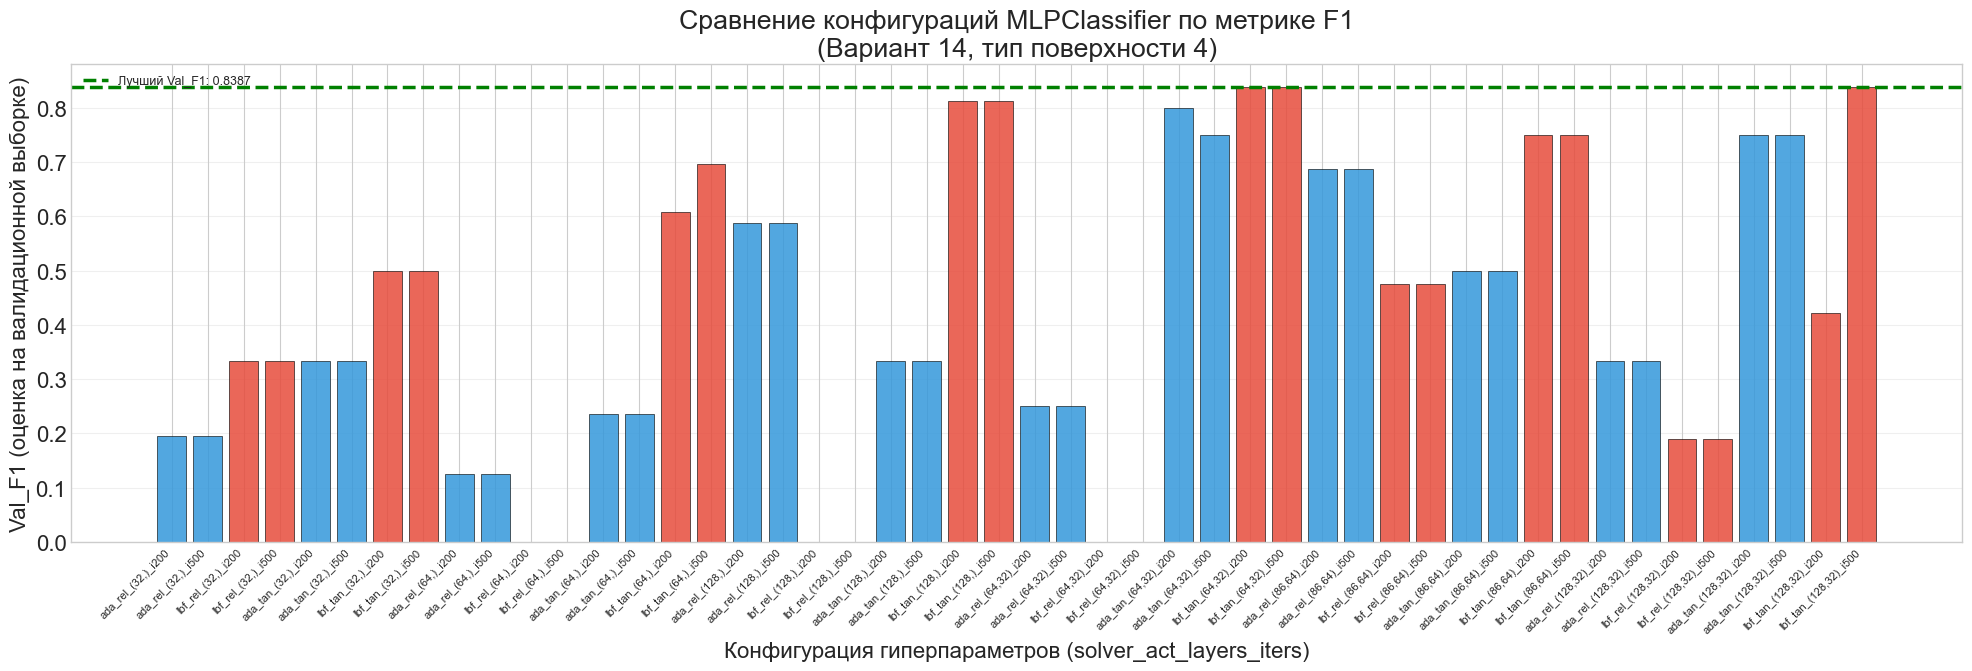


Топ-5 конфигураций по Val_F1:
(64, 32) | tanh | lbfgs | iter=200 | Val_F1=0.8387
(64, 32) | tanh | lbfgs | iter=500 | Val_F1=0.8387
(128, 32) | tanh | lbfgs | iter=500 | Val_F1=0.8387
(128,) | tanh | lbfgs | iter=200 | Val_F1=0.8125
(128,) | tanh | lbfgs | iter=500 | Val_F1=0.8125


In [20]:
import matplotlib.pyplot as plt
import os

# Настройки отображения
plt.rcParams['figure.figsize'] = (20, 7)
plt.rcParams['font.size'] = 16
plt.rcParams['legend.fontsize'] = 16  
plt.style.use('seaborn-v0_8-whitegrid')

# Формируем компактные подписи для оси X
df_results['config_label'] = (
    df_results['solver'].str[:3] + '_' + 
    df_results['activation'].str[:3] + '_' + 
    df_results['layers'].apply(lambda x: str(x).replace(' ', '')) + '_i' + 
    df_results['max_iter'].astype(str)
)

plt.figure()
colors = {'adam': '#3498db', 'lbfgs': '#e74c3c'}

plt.bar(
    range(len(df_results)), 
    df_results['val_f1'], 
    color=[colors[s] for s in df_results['solver']],
    alpha=0.85, edgecolor='black', linewidth=0.5
)

plt.xticks(range(len(df_results)), df_results['config_label'], rotation=45, ha='right', fontsize=8)

best_idx = df_results['val_f1'].idxmax()
plt.axhline(y=df_results.loc[best_idx, 'val_f1'], color='green', linestyle='--', 
            linewidth=2.5, label=f'Лучший Val_F1: {df_results.loc[best_idx, "val_f1"]:.4f}')

plt.xlabel('Конфигурация гиперпараметров (solver_act_layers_iters)')
plt.ylabel('Val_F1 (оценка на валидационной выборке)')
plt.title('Сравнение конфигураций MLPClassifier по метрике F1\n(Вариант 14, тип поверхности 4)')
plt.legend(loc='upper left', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Сохранение
os.makedirs(reports_dir, exist_ok=True)
plt.savefig(os.path.join(reports_dir, "hyperparams_val_histogram.png"), dpi=300, bbox_inches='tight')
plt.show()

# Вывод топ-5 результатов в консоль
print("\nТоп-5 конфигураций по Val_F1:")
top5 = df_results.nlargest(5, 'val_f1')[['layers', 'activation', 'solver', 'max_iter', 'val_f1', 'val_acc']]
for _, row in top5.iterrows():
    print(f"{row['layers']} | {row['activation']} | {row['solver']} | iter={row['max_iter']} | Val_F1={row['val_f1']:.4f}")

Эксперимент на исходных данных

Исходные данные | Val_Accuracy: 0.9296 | Val_F1: 0.8387


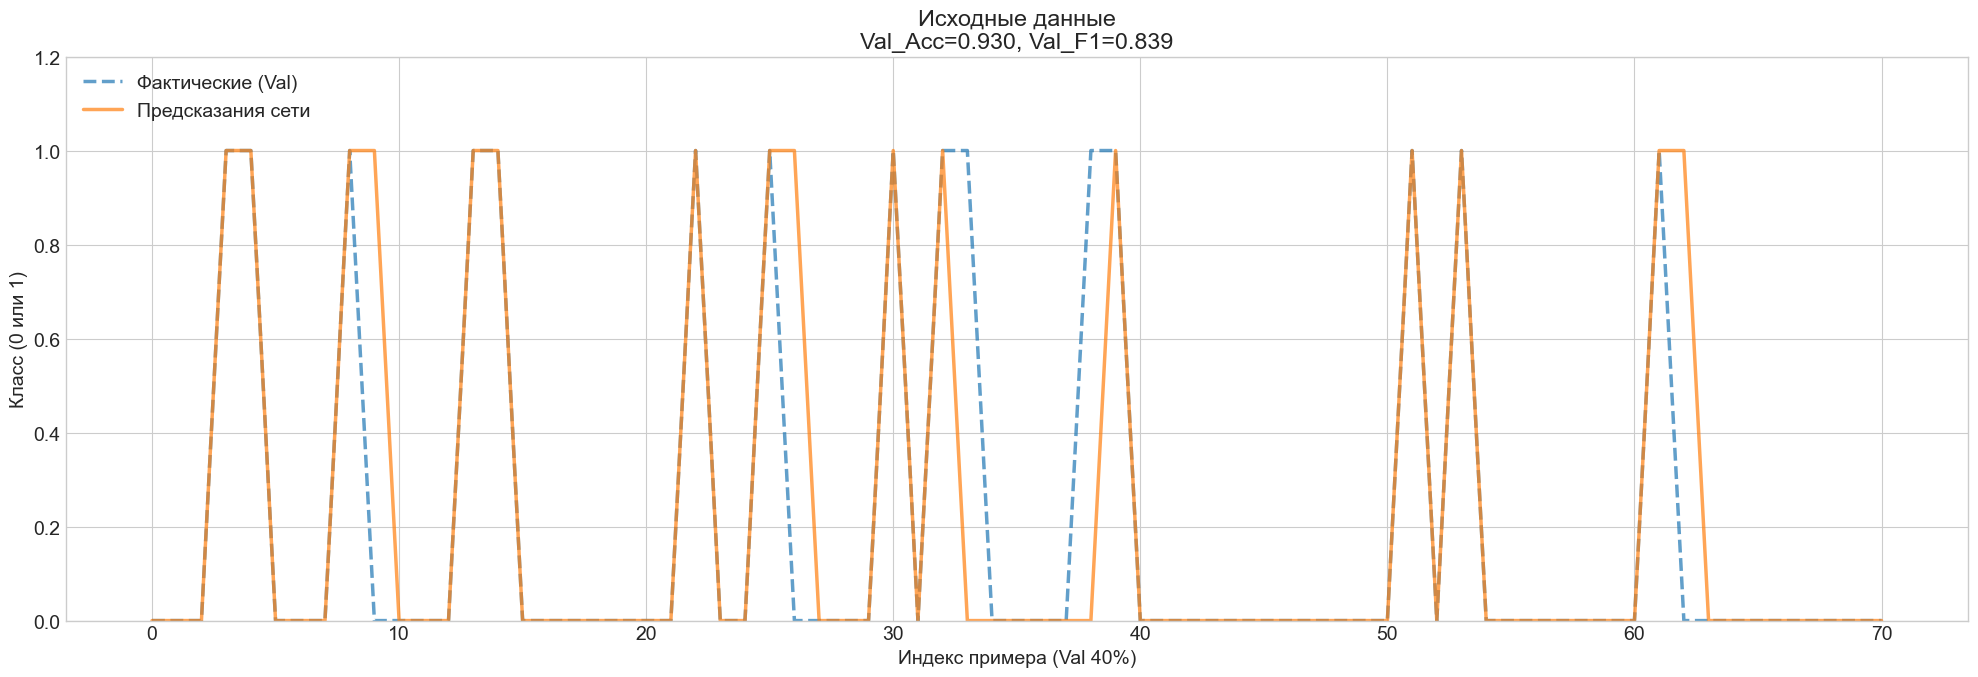

In [14]:
model_raw = MLPClassifier(**BEST_PARAMS, random_state=42)
model_raw.fit(X_train, y_train)
y_pred_val_raw = model_raw.predict(X_val)

acc_raw = accuracy_score(y_val, y_pred_val_raw)
f1_raw = f1_score(y_val, y_pred_val_raw)

print(f"Исходные данные | Val_Accuracy: {acc_raw:.4f} | Val_F1: {f1_raw:.4f}")

plt.figure()
plt.plot(y_val, label='Фактические (Val)', linewidth=2.5,   linestyle='--', alpha=0.7)
plt.plot(y_pred_val_raw, label='Предсказания сети', linewidth=2.5, alpha=0.7)
plt.xlabel('Индекс примера (Val 40%)')
plt.ylabel('Класс (0 или 1)')
plt.ylim(0, 1.2)
plt.title(f'Исходные данные\nVal_Acc={acc_raw:.3f}, Val_F1={f1_raw:.3f}')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(reports_dir, 'plot_raw_val.png'), dpi=300, bbox_inches='tight')
plt.show()

Эксперимент на отсортированных данных

Отсортированные Train | Val_Acc: 0.9014 | Val_F1: 0.6957


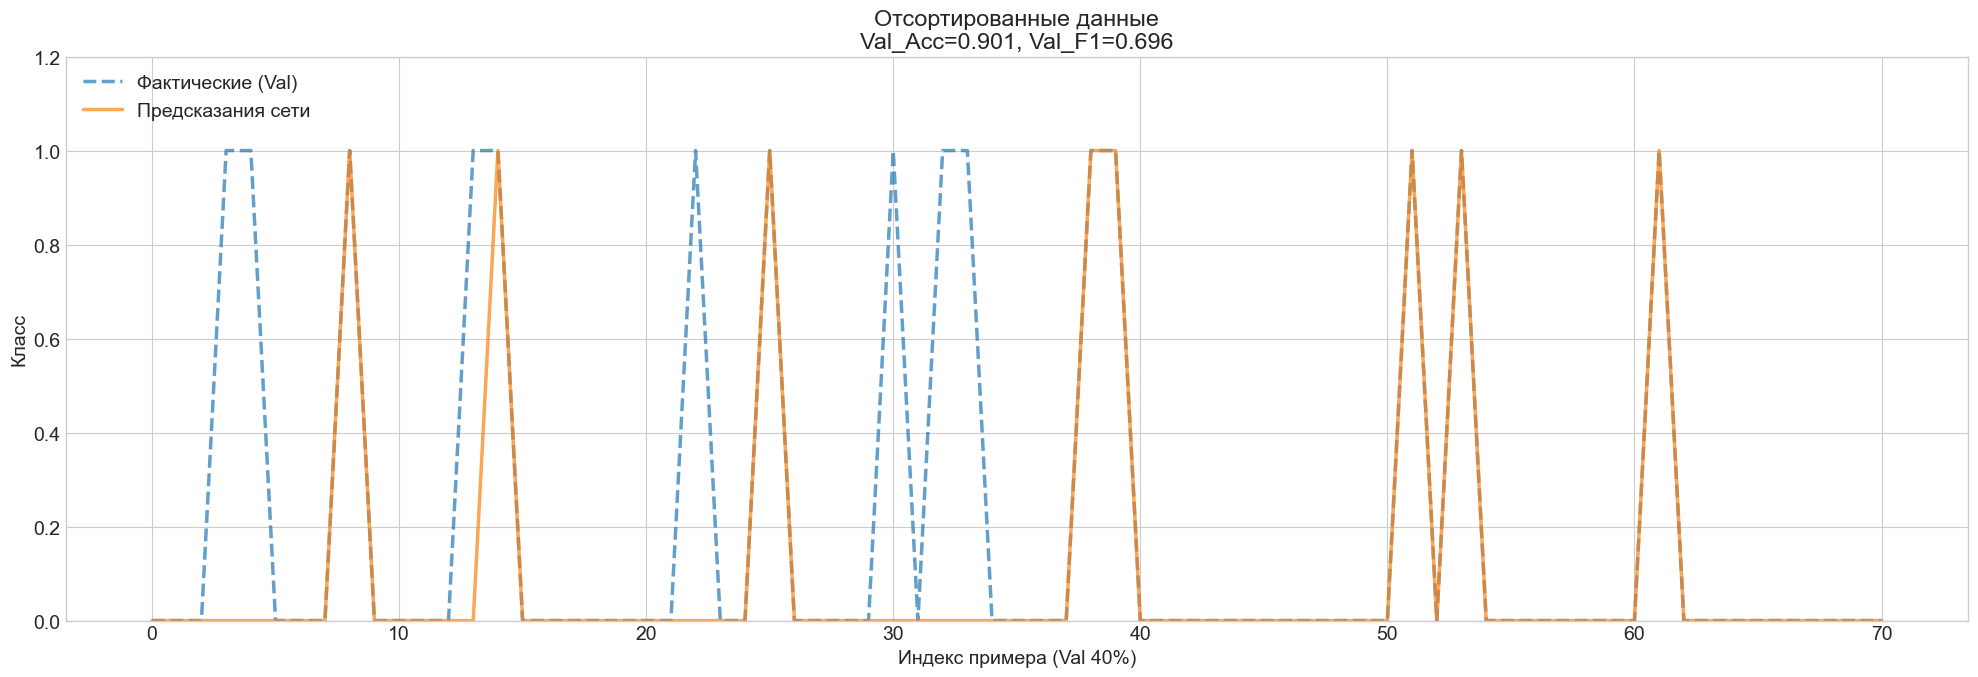

In [15]:
# Сортируем только обучающую выборку по целевому признаку
idx_sorted = np.argsort(y_train)
X_train_sort = X_train[idx_sorted]
y_train_sort = y_train[idx_sorted]

model_sort = MLPClassifier(**BEST_PARAMS, random_state=42)
model_sort.fit(X_train_sort, y_train_sort)
y_pred_val_sort = model_sort.predict(X_val)

acc_sort = accuracy_score(y_val, y_pred_val_sort)
f1_sort = f1_score(y_val, y_pred_val_sort)

print(f"Отсортированные Train | Val_Acc: {acc_sort:.4f} | Val_F1: {f1_sort:.4f}")

plt.figure()
plt.plot(y_val, label='Фактические (Val)', linewidth=2.5, linestyle='--', alpha=0.7)
plt.plot(y_pred_val_sort, label='Предсказания сети', linewidth=2.5, alpha=0.7)
plt.xlabel('Индекс примера (Val 40%)')
plt.ylabel('Класс')
plt.ylim(0, 1.2)
plt.title(f'Отсортированные данные\nVal_Acc={acc_sort:.3f}, Val_F1={f1_sort:.3f}')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(reports_dir, 'plot_sorted_val.png'), dpi=300, bbox_inches='tight')
plt.show()

Эксперимент на нормализованных данных

Нормализованные данные | Val_Acc: 0.9718 | Val_F1: 0.9375


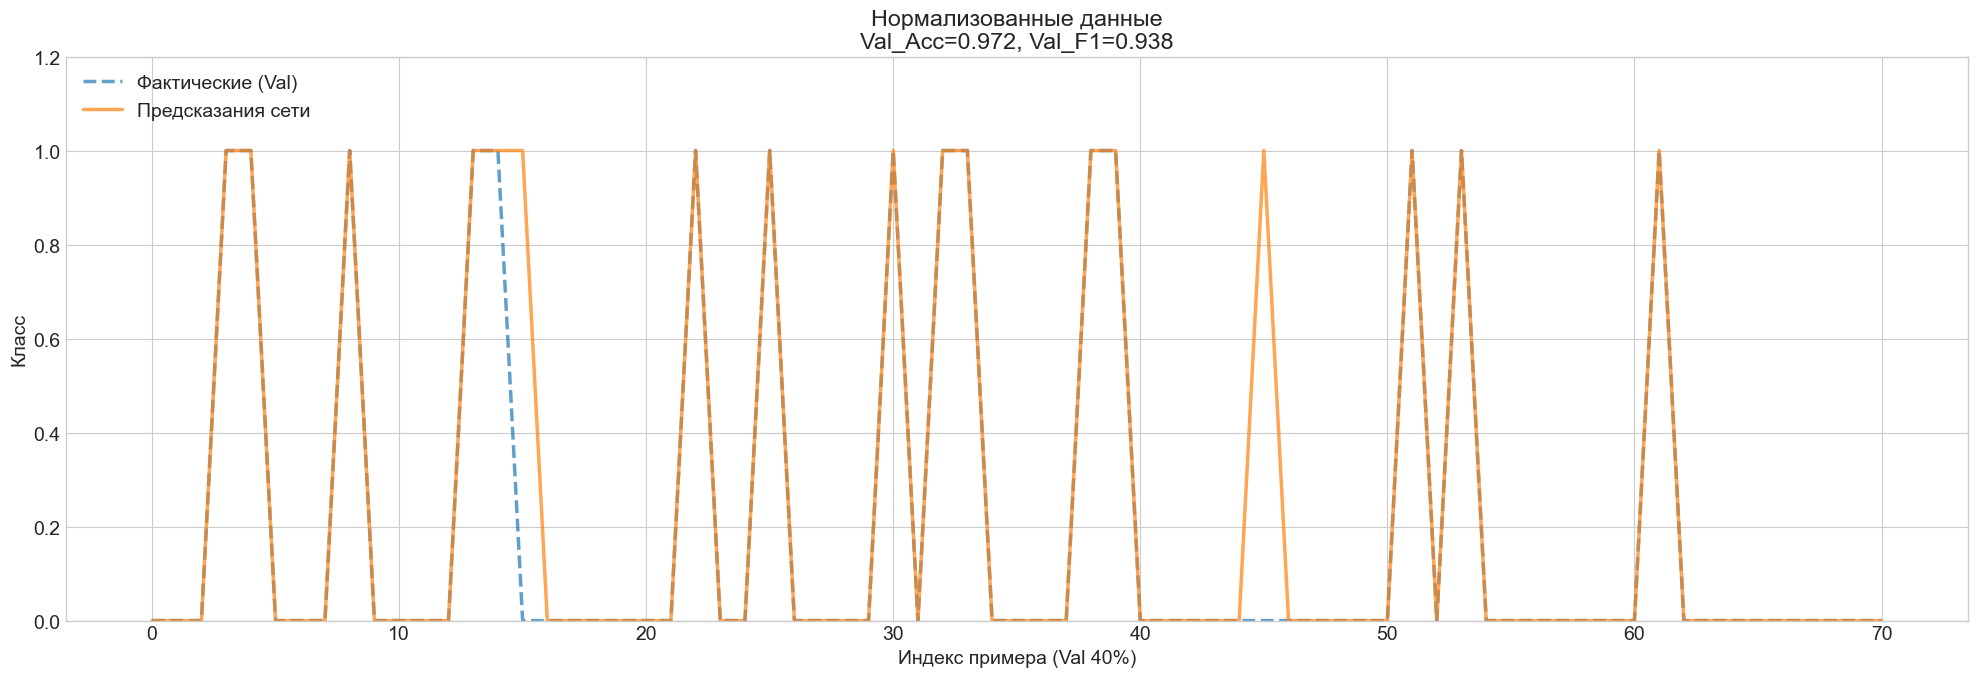

In [16]:
# Выбираем лучшую обучающую выборку из предыдущих шагов
use_sorted = f1_sort >= f1_raw
X_train_base = X_train_sort if use_sorted else X_train
y_train_base = y_train_sort if use_sorted else y_train

scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train_base)  # fit ТОЛЬКО на train
X_val_norm = scaler.transform(X_val)               # transform на val (без утечки!)

model_norm = MLPClassifier(**BEST_PARAMS, random_state=42)
model_norm.fit(X_train_norm, y_train_base)
y_pred_val_norm = model_norm.predict(X_val_norm)

acc_norm = accuracy_score(y_val, y_pred_val_norm)
f1_norm = f1_score(y_val, y_pred_val_norm)

print(f"Нормализованные данные | Val_Acc: {acc_norm:.4f} | Val_F1: {f1_norm:.4f}")

plt.figure()
plt.plot(y_val, label='Фактические (Val)', linewidth=2.5, linestyle='--', alpha=0.7)
plt.plot(y_pred_val_norm, label='Предсказания сети', linewidth=2.5, alpha=0.7)
plt.xlabel('Индекс примера (Val 40%)')
plt.ylabel('Класс')
plt.ylim(0, 1.2)
plt.title(f'Нормализованные данные\nVal_Acc={acc_norm:.3f}, Val_F1={f1_norm:.3f}')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(reports_dir, 'plot_norm_val.png'), dpi=300, bbox_inches='tight')
plt.show()

Эксперимент на сбалансированных данных

SMOTE  | Val_Acc: 0.9296 | Val_F1: 0.8387
ADASYN | Val_Acc: 0.9296 | Val_F1: 0.8387
✅ Лучший метод балансировки на Val: SMOTE


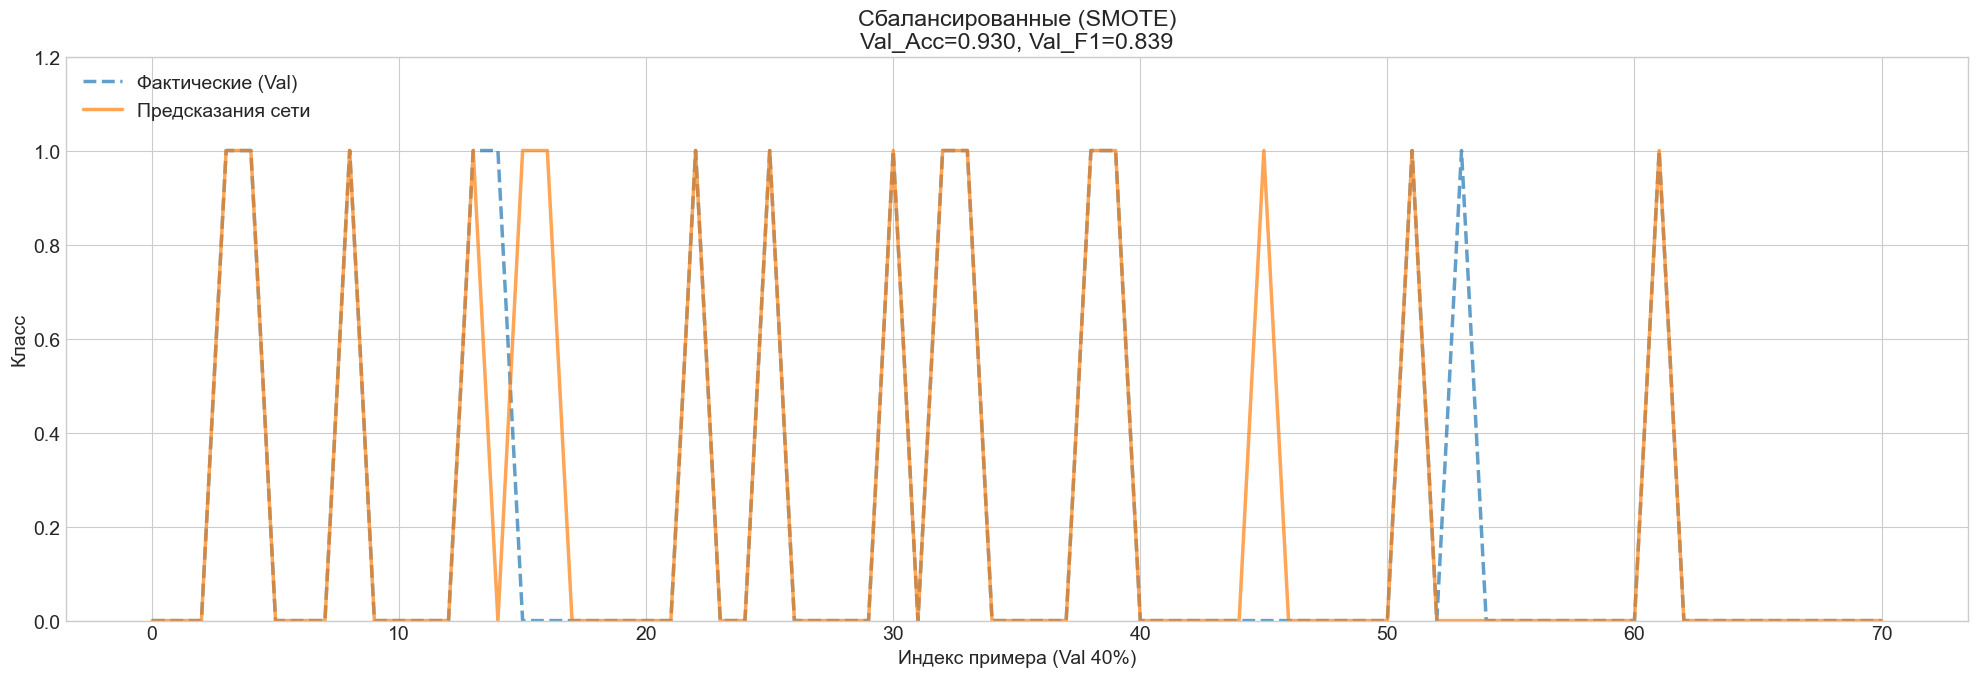

In [ ]:
# Балансировка ТОЛЬКО обучающей нормализованной выборки
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_norm, y_train_base)

adasyn = ADASYN(random_state=42)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train_norm, y_train_base)

# Оценка SMOTE
model_smote = MLPClassifier(**BEST_PARAMS, random_state=42)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_val_smote = model_smote.predict(X_val_norm)
f1_smote = f1_score(y_val, y_pred_val_smote)
acc_smote = accuracy_score(y_val, y_pred_val_smote)

# Оценка ADASYN
model_ada = MLPClassifier(**BEST_PARAMS, random_state=42)
model_ada.fit(X_train_ada, y_train_ada)
y_pred_val_ada = model_ada.predict(X_val_norm)
f1_ada = f1_score(y_val, y_pred_val_ada)
acc_ada = accuracy_score(y_val, y_pred_val_ada)

print(f"SMOTE  | Val_Acc: {acc_smote:.4f} | Val_F1: {f1_smote:.4f}")
print(f"ADASYN | Val_Acc: {acc_ada:.4f} | Val_F1: {f1_ada:.4f}")

best_bal = 'SMOTE' if f1_smote >= f1_ada else 'ADASYN'
print(f"Лучший метод балансировки на Val: {best_bal}")

y_pred_best = y_pred_val_smote if best_bal == 'SMOTE' else y_pred_val_ada
f1_best = f1_smote if best_bal == 'SMOTE' else f1_ada
acc_best = acc_smote if best_bal == 'SMOTE' else acc_ada

plt.figure()
plt.plot(y_val, label='Фактические (Val)', linewidth=2.5, linestyle='--', alpha=0.7)
plt.plot(y_pred_best, label='Предсказания сети', linewidth=2.5, alpha=0.7)
plt.xlabel('Индекс примера (Val 40%)')
plt.ylabel('Класс')
plt.ylim(0, 1.2)
plt.title(f'Сбалансированные ({best_bal})\nVal_Acc={acc_best:.3f}, Val_F1={f1_best:.3f}')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(reports_dir, f'plot_bal_{best_bal}_val.png'), dpi=300, bbox_inches='tight')
plt.show()

Проверка на контрольной выборке C

РЕЗУЛЬТАТ НА КОНТРОЛЬНОЙ ВЫБОРКЕ C
Test_Accuracy: 0.9483
Test_F1-Score: 0.8889
Параметры сети: {'hidden_layer_sizes': (64, 32), 'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 200}
Пайплайн: Нормализация (без балансировки)
                precision    recall  f1-score   support

Другой тип (0)       1.00      0.93      0.97        46
     Тип 4 (1)       0.80      1.00      0.89        12

      accuracy                           0.95        58
     macro avg       0.90      0.97      0.93        58
  weighted avg       0.96      0.95      0.95        58



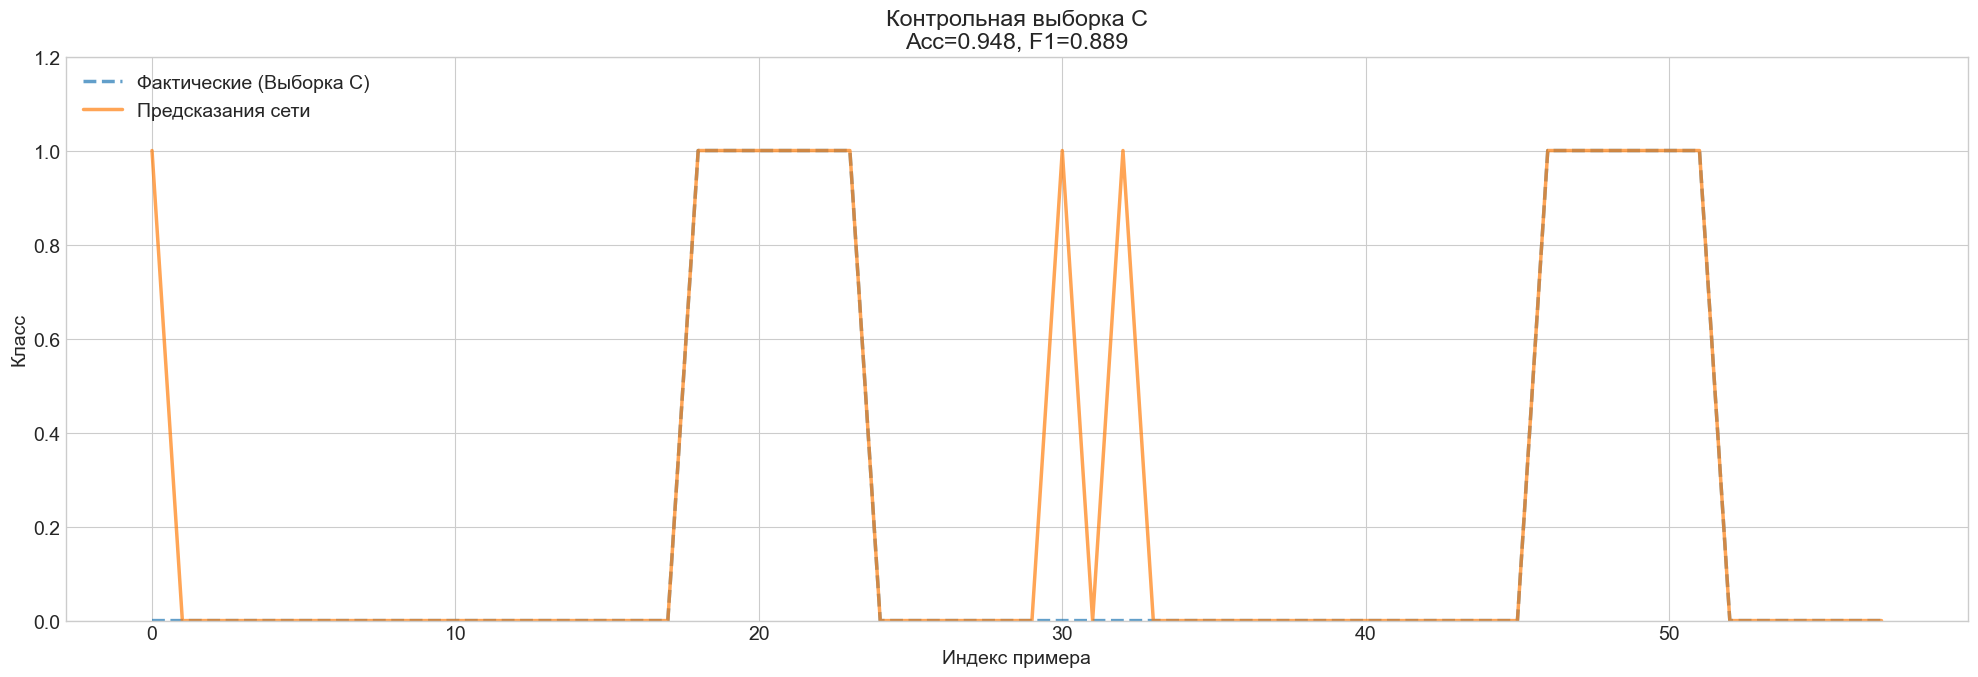

In [18]:
# Загрузка и очистка выборки C
df_test = pd.read_csv(test_path, sep=';', decimal=',', encoding='cp1251')
for col in feature_cols + ['Type']:
    df_test[col] = pd.to_numeric(df_test[col], errors='coerce')
df_test.replace([np.inf, -np.inf], np.nan, inplace=True)
df_test = df_test.dropna(subset=feature_cols + ['Type']).reset_index(drop=True)

y_test = (df_test['Type'] == 4).astype(int).values
X_test = df_test[feature_cols].values

# Применяем ТОЛЬКО нормализацию
X_test_norm = scaler.transform(X_test)

#Выбираем модель, показавшую лучший Val_F1 
final_model = model_norm 

y_pred_test = final_model.predict(X_test_norm)

#Оценка метрик
acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

print("=" * 60)
print("РЕЗУЛЬТАТ НА КОНТРОЛЬНОЙ ВЫБОРКЕ C")
print(f"Test_Accuracy: {acc_test:.4f}")
print(f"Test_F1-Score: {f1_test:.4f}")
print(f"Параметры сети: {BEST_PARAMS}")
print(f"Пайплайн: Нормализация (без балансировки)")
print("=" * 60)

print(classification_report(y_test, y_pred_test, target_names=['Другой тип (0)', 'Тип 4 (1)']))

# График
plt.figure()
plt.plot(y_test, label='Фактические (Выборка C)', linewidth=2.5, linestyle='--', alpha=0.7)
plt.plot(y_pred_test, label='Предсказания сети', linewidth=2.5, alpha=0.7)
plt.xlabel('Индекс примера')
plt.ylabel('Класс')
plt.ylim(0, 1.2)
plt.title(f'Контрольная выборка C\nAcc={acc_test:.3f}, F1={f1_test:.3f}')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(reports_dir, 'plot_test_C.png'), dpi=300, bbox_inches='tight')
plt.show()